In [1]:
from massfuncs import get_GSMF_Adams, get_GSMF_Bernardi, get_GSMF_GAMA, get_HMF
from BAM import AbundanceMatch, proxies
from colossus.cosmology import cosmology
from colossus.halo import profile_nfw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binned_statistic

In [2]:
SCATTER = 0.2

GAL_NAME = 'ESO563-G021'

L_bulge = 0.0   #automatize it later

M2L_disk_mean = 0.5
M2L_disk_error = 0.125

M2L_bulge_mean = 0.7
M2L_bulge_error = 0.175

In [3]:
GAMA_mode = 'bolometric'
A_stellar_masses, A_GSMF = get_GSMF_Adams(redshift=0, plotting=False)
B_stellar_masses, B_GSMF = get_GSMF_Bernardi(plotting=False)
G_stellar_masses, G_GSMF = get_GSMF_GAMA(mode=GAMA_mode)
H_masses, H_HMF = get_HMF(redshift=0, plotting=False)
ELPETRO_SMF = np.load("SMF_NSA_ELPETRO_Z015_h07.npy")

/Users/fedorboreiko/Documents/Oxford/btfr_z/massfuncs.py:59: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('Tabular_data/MsF_cmodel.dat', delim_whitespace=True, names=column_names)


/var/folders/l7/q8q6j9pn36b27d9322g4ysgc0000gn/T/ipykernel_44598/3502396154.py:19: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(1e-7, 0)


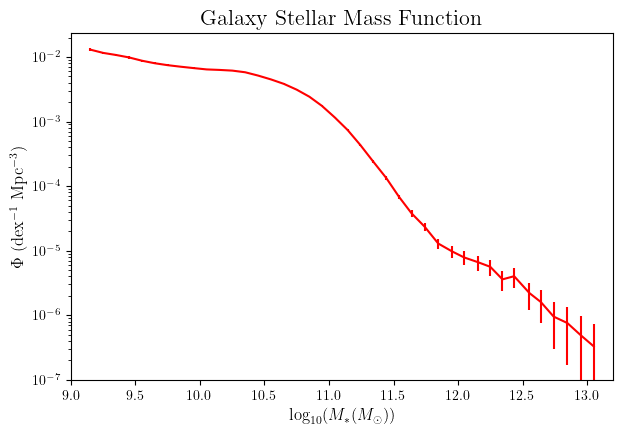

In [4]:
import matplotlib.ticker as ticker
from matplotlib import rcParams

# Set the font to Computer Modern (LaTeX default) and enable LaTeX rendering
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

fig, ax = plt.subplots(figsize=(7, 4.5))
#ax.plot(log_A_stellar_masses, A_GSMF, label='Adams, SExtractor+IRAC, z=0', color='cyan')
ax.errorbar(ELPETRO_SMF["proxy"][10:], ELPETRO_SMF["phi"][10:]*0.7**3, ELPETRO_SMF["err"][10:], label='NSA_ELPETRO', color='red')
#ax.scatter(B_stellar_masses[5:], B_GSMF[5:], label='Bernardi', color='purple', s=6)
#ax.plot(H_masses, H_HMF, label=f'GAMA, {GAMA_mode}', color='blue', alpha=0.7)
ax.set_yscale('log')
# Update axis labels with Times New Roman font
ax.set_xlabel(r'$\log_{10}(M_* (M_\odot))$', fontsize=12) 
ax.set_ylabel(r'$\Phi\ \mathrm{(dex^{-1}\ Mpc^{-3})}$', fontsize=12)
ax.set_xlim(9, 13.2)
ax.set_ylim(1e-7, 0)
# Update title with better font
ax.set_title('Galaxy Stellar Mass Function', fontsize=16)
#ax.legend()

plt.savefig('plots/GSMF_comparison.png', dpi=300)

In [5]:
halos = np.load("/Users/fedorboreiko/Documents/Oxford/Personal_codes/Codebase/halos_z_0p00.npy")

proxy = proxies["mvir_proxy"]()

In [6]:
'''abundance_match_NSA = AbundanceMatch(ELPETRO_SMF["proxy"][10:], ELPETRO_SMF["phi"][10:]*0.7**3, halo_proxy=proxy, ext_range=(6.0, 12.0),
                                    boxsize=140, faint_end_first=True, scatter_mult=1, faint_end_slope=-0.42)  #faint_end_fit_points=10'''

abundance_match_GAMA = AbundanceMatch(G_stellar_masses, G_GSMF, halo_proxy=proxy, ext_range=(4.0, 12.0),
                                    boxsize=140, faint_end_first=True, scatter_mult=1)

#abundance_match_Adams = AbundanceMatch(log_A_stellar_masses, A_GSMF, halo_proxy=proxy, ext_range=(6.0, 12.0),
#                                   boxsize=140, faint_end_first=True, scatter_mult=1)

'''abundance_match_Bernardi = AbundanceMatch(B_stellar_masses[5:], B_GSMF[5:], halo_proxy=proxy, ext_range=(6.0, 12.0),
                                    boxsize=140, faint_end_first=True, scatter_mult=1, faint_end_slope=-0.42)'''

'abundance_match_Bernardi = AbundanceMatch(B_stellar_masses[5:], B_GSMF[5:], halo_proxy=proxy, ext_range=(6.0, 12.0),\n                                    boxsize=140, faint_end_first=True, scatter_mult=1, faint_end_slope=-0.42)'

In [7]:
theta_NSA = {"alpha": 1.2, "scatter": 0.2}
theta_GAMA = {"alpha": 5, "scatter": 0.2}
theta_Adams = {"alpha": 1.2, "scatter": 0.2}
theta_Bernardi = {"alpha": 1.2, "scatter": 0.2}

#deconv_NSA = abundance_match_NSA.deconvoluted_catalogs(theta_NSA, halos)
deconv_GAMA = abundance_match_GAMA.deconvoluted_catalogs(theta_GAMA, halos)
#deconv_Adams = abundance_match_Adams.deconvoluted_catalogs(theta_Adams, halos)
#deconv_Bernardi = abundance_match_Bernardi.deconvoluted_catalogs(theta_Bernardi, halos)

In [8]:
#mask_N, catalog_N = abundance_match_NSA.add_scatter(deconv_NSA, cut_range=(7, 12), return_catalog=True)
mask_G, catalog_G = abundance_match_GAMA.add_scatter(deconv_GAMA, cut_range=(4, 12), return_catalog=True)
#mask_A, catalog_A = abundance_match_Adams.add_scatter(deconv_Adams, cut_range=(7, 12), return_catalog=True)
#mask_B, catalog_B = abundance_match_Bernardi.add_scatter(deconv_Bernardi, cut_range=(7, 12), return_catalog=True)

#halo_proxy_N = proxy(halos, {"alpha": 0.01})[mask_N]
halo_proxy_G = proxy(halos, {"alpha": 5})[mask_G]
#halo_proxy_A = proxy(halos, {"alpha": 0.01})[mask_A]
#halo_proxy_B = proxy(halos, {"alpha": 0.01})[mask_B]

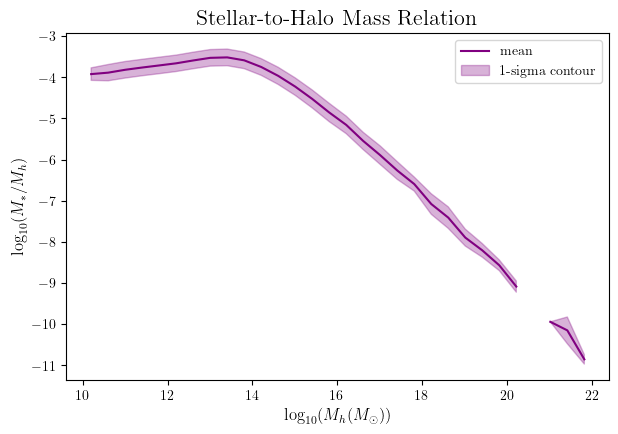

In [9]:
def plot_SHMR_with_contours(halo_proxy, stellar_mass, color):
    # Bin data
    bin_means, bin_edges, binnumber = binned_statistic(halo_proxy, stellar_mass, statistic='mean', bins=30)
    bin_std, _, _ = binned_statistic(halo_proxy, stellar_mass, statistic='std', bins=30)
    
    # Bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Plot mean and 1-sigma contours
    plt.plot(bin_centers, bin_means, color=color, label=f'mean')
    plt.fill_between(bin_centers, bin_means - bin_std, bin_means + bin_std, color=color, alpha=0.3, label=f'1-sigma contour')

fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot SHMR for NSA
#plot_SHMR_with_contours(halo_proxy_N, catalog_N-halo_proxy_N, color='red', label='NSA')
plot_SHMR_with_contours(halo_proxy_G, catalog_G-halo_proxy_G, color='purple')
#plot_SHMR_with_contours(halo_proxy_A, catalog_A-halo_proxy_A, color='purple', label='Adams')
#plot_SHMR_with_contours(halo_proxy_B, catalog_B-halo_proxy_B, color='purple', label='Bernardi')

ax.set_ylabel(r'$\log_{10}(M_*/M_h)$', fontsize=12) 
ax.set_xlabel(r'$\log_{10}(M_h (M_\odot))$', fontsize=12) 
ax.set_title("Stellar-to-Halo Mass Relation", fontsize=16)
ax.legend()

plt.savefig('plots/SHMR_contours.png', dpi=300)